### Clustering using scikit-learn (with pandas and matplotlib)

In [2]:
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import cluster
from scipy.spatial.distance import cdist
from scipy.cluster.hierarchy import dendrogram, linkage
%matplotlib inline

In [3]:
import numpy as np
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
ruta = '/content/drive/MyDrive/Clase5 - Laboratorio/Clase5 - Laboratorio'
cities = pd.read_csv('%s/developer_burnout_dataset_7000.csv'%ruta)
cities.head()

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
0,26.0,12.0,10.33,4.45,2.0,11.0,4.0,1.0,15.07,0.14,55.96,Medium
1,39.0,10.0,8.62,5.77,5.0,15.0,11.0,5.0,13.25,0.54,82.22,High
2,34.0,13.0,NaN,4.03,5.0,2.0,18.0,9.0,11.18,1.54,61.77,Medium
3,30.0,1.0,6.85,6.47,2.0,15.0,26.0,1.0,11.14,0.96,54.98,Medium
4,27.0,7.0,4.24,5.80,NaN,9.0,17.0,7.0,8.05,0.36,27.90,Low


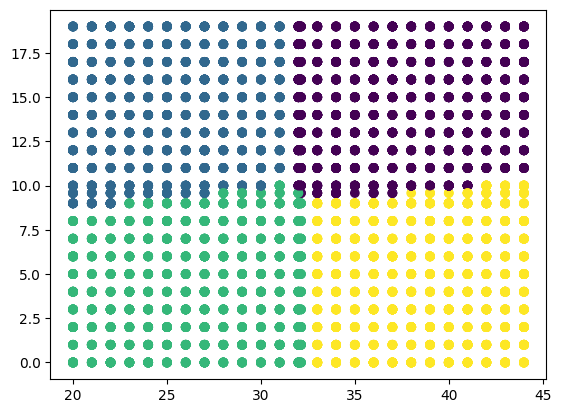

In [45]:

kmeans = cluster.KMeans(4)

cities['age'] = cities['age'].fillna(cities['age'].mean())
cities['experience_years'] = cities['experience_years'].fillna(cities['experience_years'].mean())
kmeans.fit(cities[['age', 'experience_years']])
labels = kmeans.labels_
plt.scatter(cities['age'], cities['experience_years'], c=labels)
plt.show()
centroids = kmeans.cluster_centers_

In [18]:
centroids

array([[37.4954269 ,  4.56728436],
       [26.42853229, 14.60907687],
       [38.80468304, 14.3490432 ],
       [25.31971581,  4.84298142]])

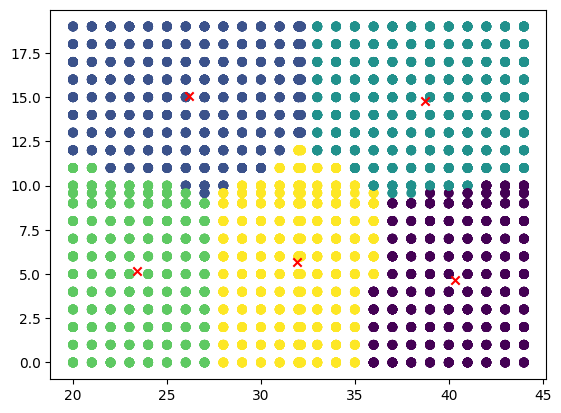

In [21]:
# Con los centroides
kmeans = cluster.KMeans(5, random_state=0)
# Ensure 'age' and 'experience_years' columns have no NaN values before clustering
cities['age'] = cities['age'].fillna(cities['age'].mean())
cities['experience_years'] = cities['experience_years'].fillna(cities['experience_years'].mean())
kmeans.fit(cities[['age', 'experience_years']])
labels = kmeans.labels_
centroids = kmeans.cluster_centers_
plt.scatter(cities['age'], cities['experience_years'], c=labels)
plt.scatter(centroids[:,0], centroids[:,1], marker='x', c='red')
plt.show()

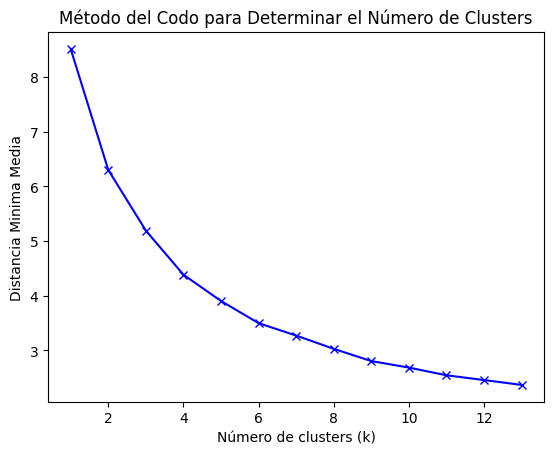

In [24]:
distortions = []
K = range(1,14)
for k in K:
    kmeanModel = cluster.KMeans(n_clusters=k, random_state=0).fit(cities[['age', 'experience_years']])
    distortions.append(sum(np.min(cdist(cities[['age', 'experience_years']], kmeanModel.cluster_centers_,
                                        'euclidean'), axis=1)) / cities[['age', 'experience_years']].shape[0])

plt.plot(K, distortions, 'bx-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Distancia Minima Media')
plt.title('Método del Codo para Determinar el Número de Clusters')
plt.show()

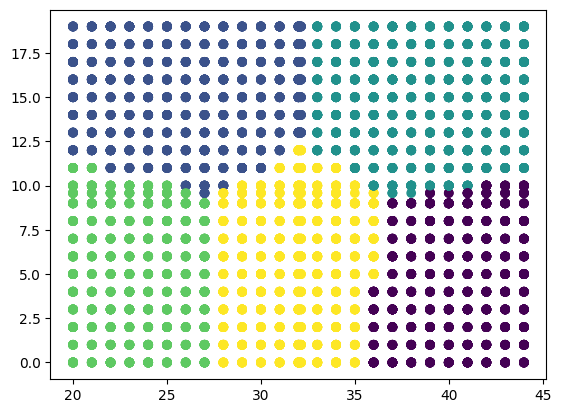

In [27]:
cities['age'] = cities['age'].fillna(cities['age'].mean())
cities['experience_years'] = cities['experience_years'].fillna(cities['experience_years'].mean())

# K-means clustering based on age and experience_years
kmeans = cluster.KMeans(5, random_state=0)
kmeans.fit(cities[['age', 'experience_years']])
labels = kmeans.labels_
plt.scatter(cities['age'], cities['experience_years'], c=labels)
plt.show()
centroids = kmeans.cluster_centers_

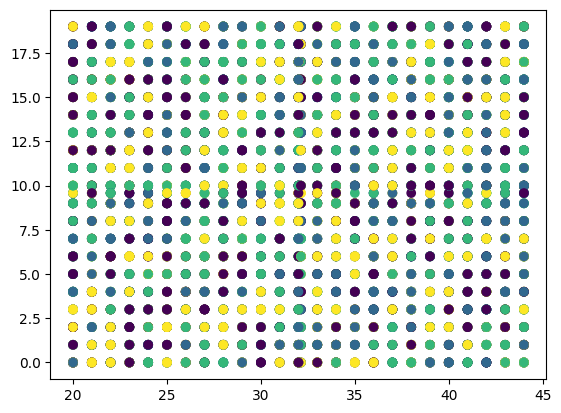

[[12.68625351]
 [ 7.55176163]
 [ 9.99009791]
 [ 5.18318037]]


In [32]:
cities['age'] = cities['age'].fillna(cities['age'].mean())
cities['experience_years'] = cities['experience_years'].fillna(cities['experience_years'].mean())
cities['daily_work_hours'] = cities['daily_work_hours'].fillna(cities['daily_work_hours'].mean())

# K-means clustering based on daily_work_hours, age and experience_years
kmeans = cluster.KMeans(4, random_state=0)
kmeans.fit(cities[['daily_work_hours']])
labels = kmeans.labels_
centroids = kmeans.cluster_centers_
plt.scatter(cities['age'], cities['experience_years'], c=labels)
plt.show()
print(centroids)

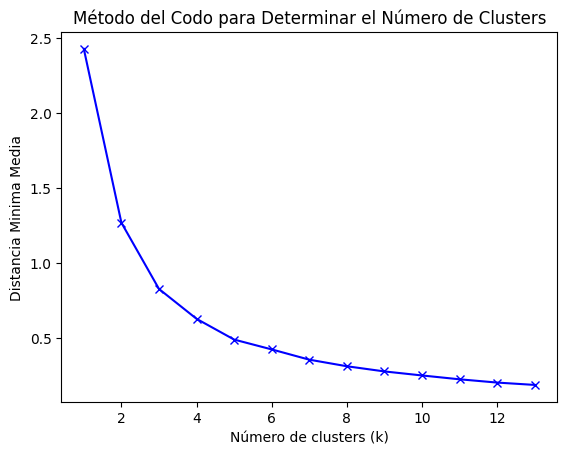

In [35]:
cities['age'] = cities['age'].fillna(cities['age'].mean())
cities['experience_years'] = cities['experience_years'].fillna(cities['experience_years'].mean())
cities['daily_work_hours'] = cities['daily_work_hours'].fillna(cities['daily_work_hours'].mean())

distortions = []
K = range(1,14)
for k in K:
    kmeanModel = cluster.KMeans(n_clusters=k, random_state=0).fit(cities[['daily_work_hours']])
    distortions.append(sum(np.min(cdist(cities[['daily_work_hours']], kmeanModel.cluster_centers_,
                                        'euclidean'), axis=1)) / cities[['daily_work_hours']].shape[0])

plt.plot(K, distortions, 'bx-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Distancia Minima Media')
plt.title('Método del Codo para Determinar el Número de Clusters')
plt.show()

In [36]:
df_city = cities.sample(10)
df_city

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
25,20.000000,18.0,5.23,5.04,5.0,2.0,19.0,1.0,9.13,0.18,27.93,Low
3685,44.000000,15.0,5.25,4.88,3.0,8.0,25.0,5.0,7.91,1.55,37.63,Medium
3389,32.129446,6.0,12.15,6.26,3.0,3.0,23.0,0.0,13.61,0.51,41.88,Medium
3307,32.129446,17.0,11.26,4.68,6.0,5.0,29.0,7.0,13.85,1.07,56.82,Medium
2995,42.000000,10.0,7.75,7.01,6.0,9.0,4.0,9.0,10.97,1.13,43.68,Medium
3031,36.000000,19.0,8.61,8.39,7.0,5.0,18.0,4.0,11.76,0.83,33.94,Low
5220,38.000000,0.0,6.77,8.16,NaN,9.0,18.0,1.0,8.79,1.12,37.79,Medium
2350,33.000000,6.0,12.71,4.30,5.0,5.0,4.0,9.0,15.70,0.45,90.34,High
3532,43.000000,5.0,5.04,4.29,1.0,19.0,27.0,0.0,8.64,1.72,31.07,Low
4569,36.000000,10.0,11.80,5.33,0.0,12.0,11.0,7.0,14.13,1.54,77.77,High


In [42]:
distancias = linkage(df_city[['daily_work_hours']].values, 'single')
etiquetas = df_city.daily_work_hours.values

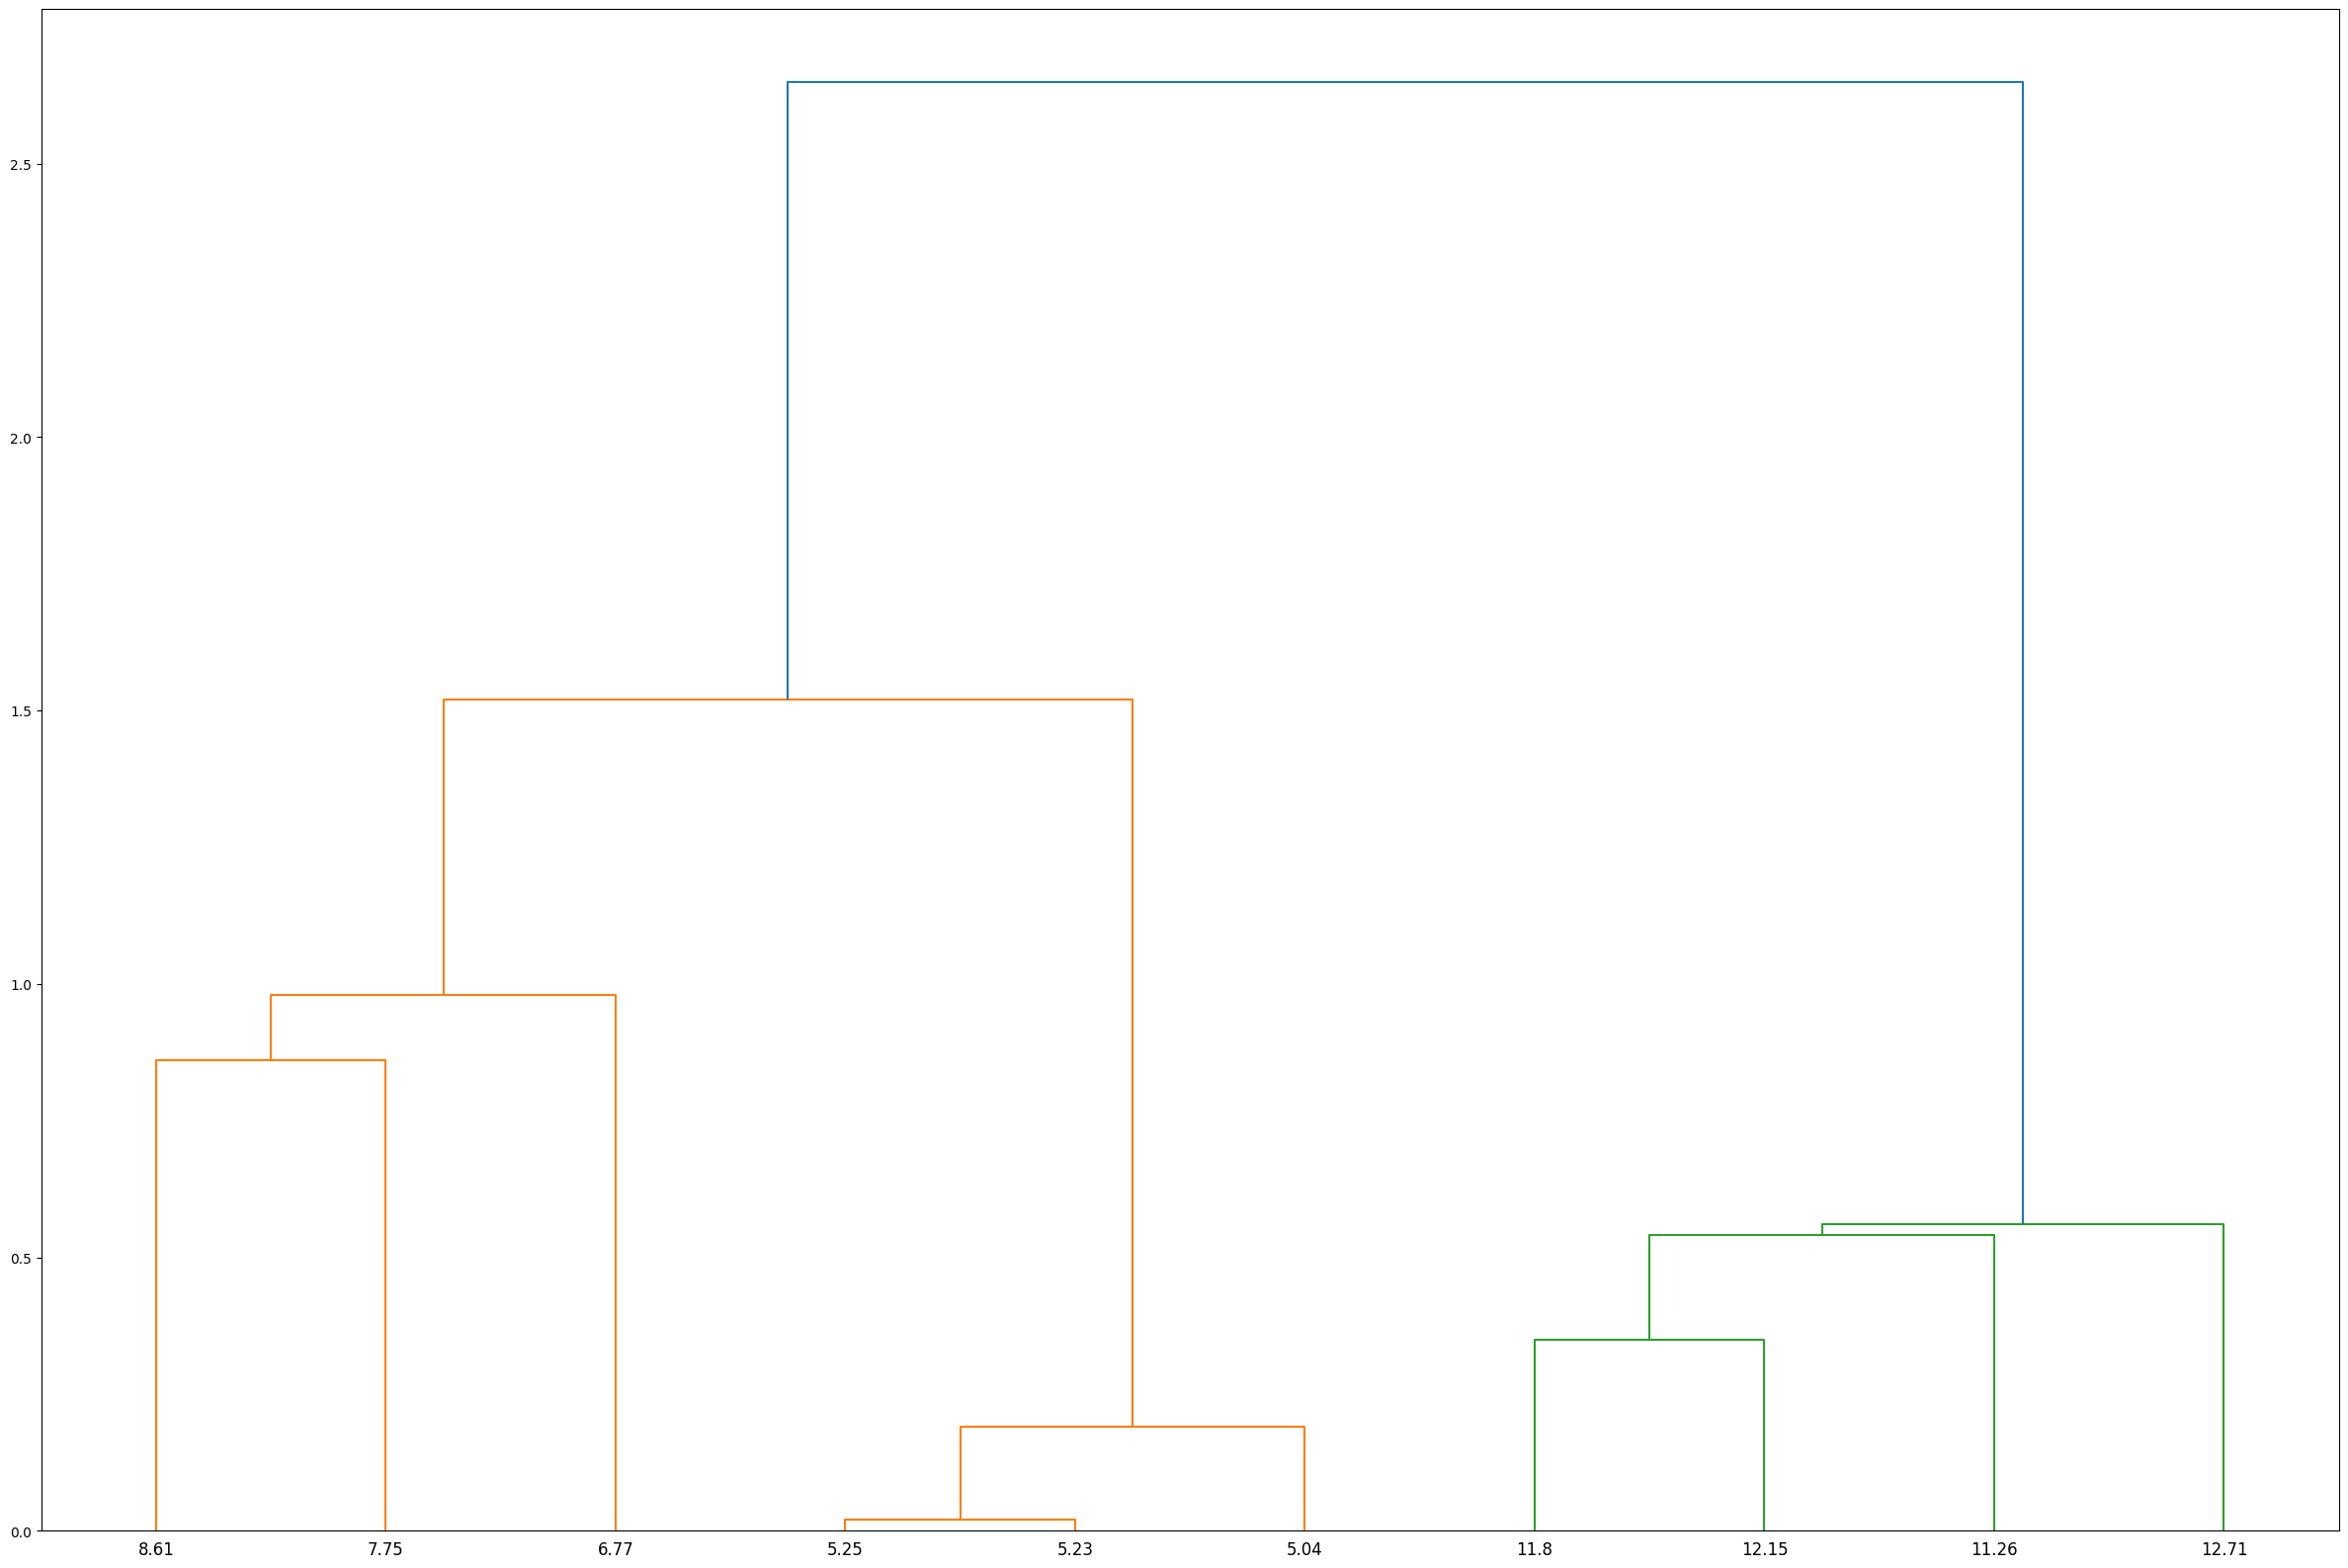

In [44]:
plt.figure(figsize=(30, 20))
dendrogram(distancias, orientation='top',labels = etiquetas, distance_sort='descending',show_leaf_counts=True)
plt.show()